# SL-CBM Results — CUB with CREAM weights

In [20]:
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── change this to your run folder ──────────────────────────────────────────
RUN_DIR = "/home/dani00003/sl-cbm/outputs/20260722122547/evaluations"
# ────────────────────────────────────────────────────────────────────────────

acc      = torch.load(f"{RUN_DIR}/accuracy.pt",              map_location="cpu")
adi      = torch.load(f"{RUN_DIR}/adi_pack.pt",              map_location="cpu")
nec      = torch.load(f"{RUN_DIR}/nec.pt",                   map_location="cpu")
interv   = torch.load(f"{RUN_DIR}/intervention_taskerror.pt",map_location="cpu")

print("Keys — accuracy:", list(acc.keys()))
print("Keys — adi_pack:", list(adi.keys()))
print("Keys — nec:",      list(nec.keys()))
print("Keys — intervention:", list(interv.keys()))

Keys — accuracy: ['test_acc', 'test_concept_acc']
Keys — adi_pack: ['concepts_avg_drop', 'concepts_avg_inc', 'concepts_avg_gain', 'classes_avg_drop', 'classes_avg_inc', 'classes_avg_gain']
Keys — nec: ['nec5', 'anec']
Keys — intervention: ['ag', 'rand', 'lcp', 'ucp', 'cctp']


## 1. Accuracy

In [21]:
print(f"Test Class Accuracy:   {acc['test_acc']:.2f}%")
print(f"Test Concept Accuracy: {acc['test_concept_acc']:.2f}%")

Test Class Accuracy:   66.62%
Test Concept Accuracy: 82.05%


## 2. Explainability — Average Drop / Increase / Gain (ADI)

In [22]:
import pandas as pd

adi_table = pd.DataFrame({
    "Level":    ["Concept", "Class"],
    "Avg Drop ↓": [
        round(float(adi["concepts_avg_drop"]) * 100, 2),
        round(float(adi["classes_avg_drop"])  * 100, 2),
    ],
    "Avg Inc ↑": [
        round(float(adi["concepts_avg_inc"]) * 100, 2),
        round(float(adi["classes_avg_inc"])  * 100, 2),
    ],
    "Avg Gain ↑": [
        round(float(adi["concepts_avg_gain"]) * 100, 2),
        round(float(adi["classes_avg_gain"])  * 100, 2),
    ],
})
print(adi_table.to_string(index=False))

  Level  Avg Drop ↓  Avg Inc ↑  Avg Gain ↑
Concept       28.36      37.06       22.24
  Class       30.21      36.05       22.07


## 3. Intervention — NEC / ANEC

In [23]:
print("NEC / ANEC scores:")
for k, v in nec.items():
    print(f"  {k}: {float(v):.4f}")

# correct key names
nec5_val = float(nec.get("nec5", nec.get("NEC-5", 0)))
anec_val = float(nec.get("anec", nec.get("ANEC", 0)))
print(f"\nNEC-5: {nec5_val:.2f}%  |  ANEC: {anec_val:.2f}%")

NEC / ANEC scores:
  nec5: 30.0500
  anec: 51.7000

NEC-5: 30.05%  |  ANEC: 51.70%


## 4. Intervention Curve (task error vs. # concepts corrected)

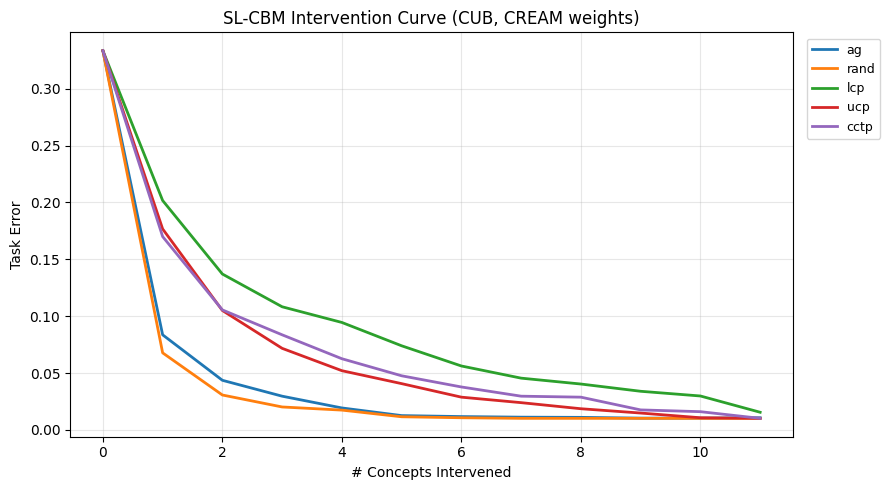

In [24]:
fig, ax = plt.subplots(figsize=(9, 5))

for method, tensor in interv.items():
    if isinstance(tensor, torch.Tensor):
        # shape: [n_batches, n_intervention_steps]
        # average task error across batches at each step
        if tensor.dim() == 2:
            y = tensor.mean(dim=0).numpy()
        else:
            y = tensor.numpy()
        x = np.arange(len(y))
        ax.plot(x, y, label=method, linewidth=2)

ax.set_xlabel("# Concepts Intervened")
ax.set_ylabel("Task Error")
ax.set_title("SL-CBM Intervention Curve (CUB, CREAM weights)")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{RUN_DIR}/intervention_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Summary Table (copy into paper comparison)

In [25]:
nec5_val = float(nec.get("nec5", nec.get("NEC-5", 0)))
anec_val  = float(nec.get("anec", nec.get("ANEC",  0)))

summary = pd.DataFrame([{
    "Method":          "SL-CBM (CREAM)",
    "Class Acc":       round(float(acc["test_acc"]), 2),
    "Concept Acc":     round(float(acc["test_concept_acc"]), 2),
    "NEC-5":           round(nec5_val, 2),
    "ANEC":            round(anec_val, 2),
    "Concept AD↓":     round(float(adi["concepts_avg_drop"]) * 100, 2),
    "Concept AI↑":     round(float(adi["concepts_avg_inc"])  * 100, 2),
    "Concept AG↑":     round(float(adi["concepts_avg_gain"]) * 100, 2),
    "Class AD↓":       round(float(adi["classes_avg_drop"])  * 100, 2),
    "Class AI↑":       round(float(adi["classes_avg_inc"])   * 100, 2),
    "Class AG↑":       round(float(adi["classes_avg_gain"])  * 100, 2),
}])

print(summary.T.to_string(header=False))

Method       SL-CBM (CREAM)
Class Acc             66.62
Concept Acc           82.05
NEC-5                 30.05
ANEC                   51.7
Concept AD↓           28.36
Concept AI↑           37.06
Concept AG↑           22.24
Class AD↓             30.21
Class AI↑             36.05
Class AG↑             22.07


## 6. Top-5 Concept Groups by Classifier Weight

In [26]:
import sys
sys.path.insert(0, "/home/dani00003/sl-cbm")
sys.path.insert(0, "/home/dani00003/pcbm-module")

from utils.constants import CUB_features

CKPT_PATH = "/home/dani00003/sl-cbm/outputs/20260722122547/trainable_weights.pt"
state = torch.load(CKPT_PATH, map_location="cpu")

# Print all keys and shapes to find the classifier weight
for k, v in state.items():
    shape = v.shape if isinstance(v, torch.Tensor) else type(v)
    print(f"  {k}: {shape}")

  simpool.norm_patches.weight: torch.Size([112])
  simpool.norm_patches.bias: torch.Size([112])
  simpool.wq.weight: torch.Size([112, 112])
  simpool.wk.weight: torch.Size([112, 112])
  token_projection.weight: torch.Size([112, 512])
  token_projection.bias: torch.Size([112])
  nec_concepts_projection.weight: torch.Size([200, 112])
  nec_concepts_projection.bias: torch.Size([200])
  classifier.0.weight: torch.Size([112])
  classifier.0.bias: torch.Size([112])
  classifier.1.weight: torch.Size([200, 112])
  classifier.1.bias: torch.Size([200])
